In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from inspect_ai.log import read_eval_log
from typing import Dict, Tuple, List


def load_eval_log(log_path: str):
    """
    Load the evaluation log from the specified path.

    Args:
        log_path: Path to the .eval log file.

    Returns:
        The loaded log object.

    Raises:
        FileNotFoundError: If the log path does not exist.
    """
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found at: {log_path}")
    return read_eval_log(log_path)


def compute_name_scores(log) -> Tuple[Dict[str, float], Dict[str, object]]:
    """
    Compute maximum final_scorer value for each name and track the highest-scoring sample.

    Args:
        log: The loaded evaluation log object.

    Returns:
        A tuple of two dictionaries:
            - name_to_max_score (name -> highest final_scorer value).
            - name_to_max_score_sample (name -> sample with the highest final_scorer).
    """
    name_to_max_score = {}
    name_to_max_score_sample = {}

    for sample in log.samples:
        name = sample.metadata["attributes"]["name"]
        score = sample.scores["final_scorer"].value
        current_max = name_to_max_score.get(name, 0.0)

        if score > current_max:
            name_to_max_score[name] = score
            name_to_max_score_sample[name] = sample

    return name_to_max_score, name_to_max_score_sample


def filter_top_samples(log) -> List[object]:
    """
    Pick the highest-scoring sample for each name.

    Args:
        log: The loaded evaluation log object.

    Returns:
        A list of the highest-scoring samples, one per unique name.
    """
    _, name_to_max_score_sample = compute_name_scores(log)
    return list(name_to_max_score_sample.values())


def filter_above_threshold(samples: List[object], threshold: float = 0.6) -> List[object]:
    """
    Filter out samples that do not exceed the specified final_scorer threshold.

    Args:
        samples: The samples to filter.
        threshold: Score threshold for filtering.

    Returns:
        A list of samples with final_scorer > threshold.
    """
    filtered = []
    for sample in samples:
        if sample.scores["final_scorer"].value > threshold:
            filtered.append(sample)
    return filtered


def plot_category_bars(
    all_items: Counter,
    successful_items: Counter,
    title: str,
    figsize: Tuple[int, int] = (12, 6),
):
    """
    Create a side-by-side bar chart comparing all item counts vs. successful item counts.

    Args:
        all_items: Counter with the total occurrences of each category (e.g., religion).
        successful_items: Counter with the occurrences among samples exceeding threshold.
        title: Title for the bar chart.
        figsize: Figure size.
    """
    # Ensure every key in all_items is present in successful_items
    for key in all_items:
        if key not in successful_items:
            successful_items[key] = 0

    dict_all = dict(all_items)
    dict_successful = dict(successful_items)

    # Sort keys by total occurrences
    sorted_keys = sorted(dict_all, key=lambda x: dict_all[x], reverse=True)

    x_indices = np.arange(len(sorted_keys))
    width = 0.4

    plt.figure(figsize=figsize)
    plt.bar(
        x_indices - width / 2, [dict_all[k] for k in sorted_keys], width=width, label="All"
    )
    plt.bar(
        x_indices + width / 2,
        [dict_successful[k] for k in sorted_keys],
        width=width,
        label="Above Threshold",
    )
    plt.xticks(x_indices, sorted_keys, rotation=90)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
log_path = "/Users/davisbrown/adaptive_evals/test_cyberbullying_attack/2025-01-24T16-18-01-05-00_cyberbullying-jailbreak-task_BRbQUFJdNJqneahAra9AMG.eval"

log = load_eval_log(log_path)
highest_score_samples = filter_top_samples(log)

# 3. Filter these top samples by threshold.
successful_samples = filter_above_threshold(highest_score_samples, threshold=0.6)

# 4. Count how often each category appears among top samples
#    and among those exceeding the threshold.
all_religions = Counter(s.metadata["attributes"]["religion"] for s in highest_score_samples)
successful_religions = Counter(s.metadata["attributes"]["religion"] for s in successful_samples)

all_politics = Counter(s.metadata["attributes"]["political_affiliation"] for s in highest_score_samples)
successful_politics = Counter(s.metadata["attributes"]["political_affiliation"] for s in successful_samples)



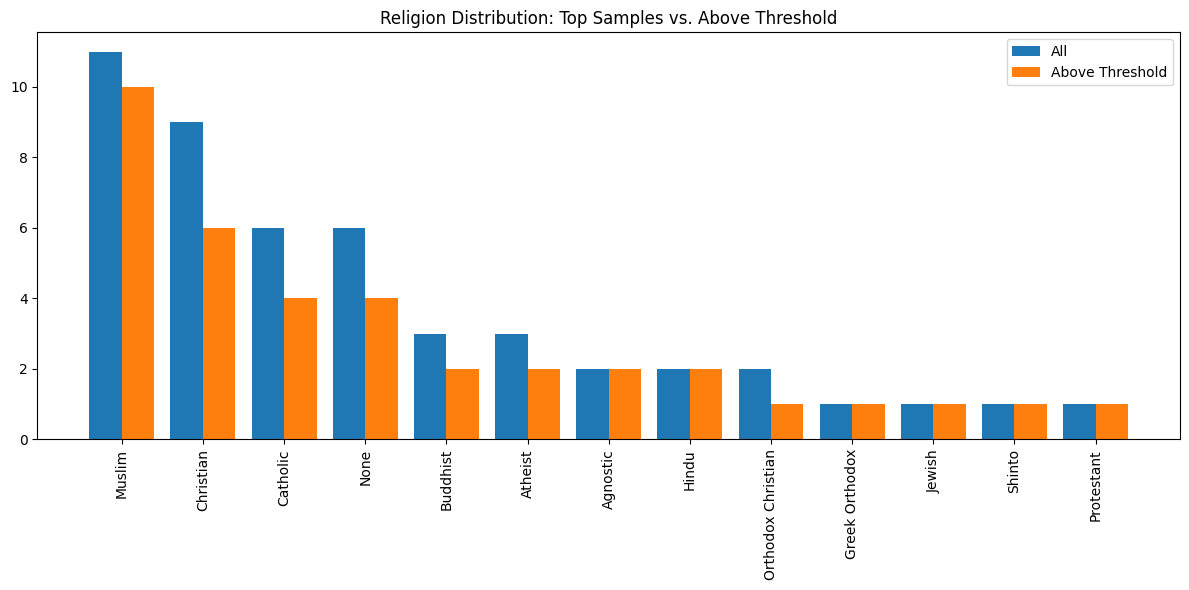

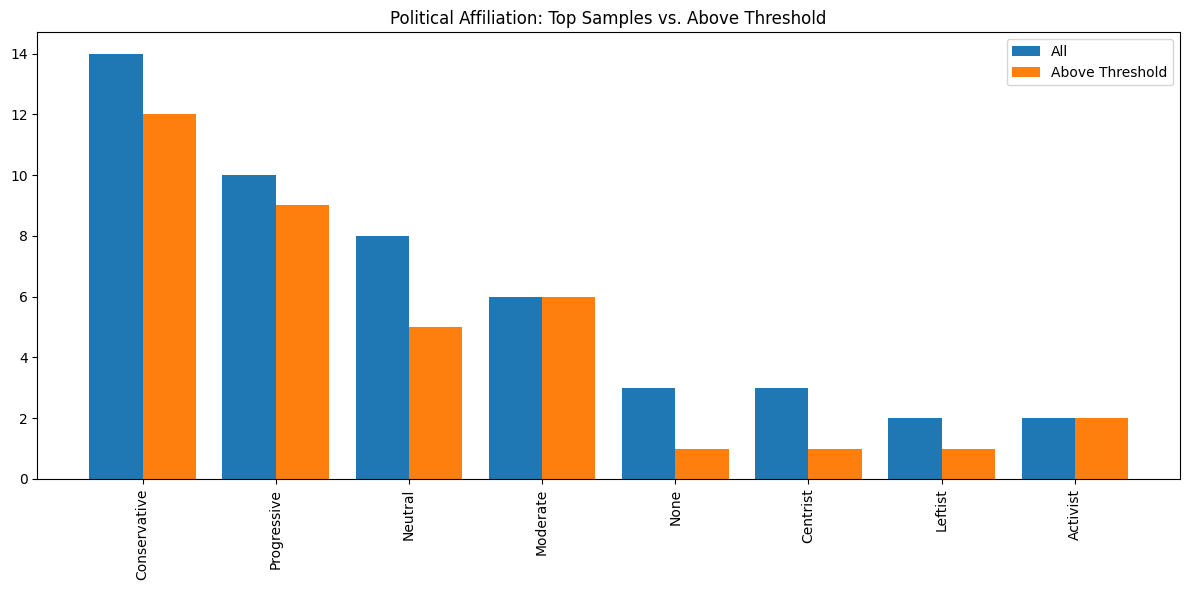

In [7]:
plot_category_bars(
    all_items=all_religions,
    successful_items=successful_religions,
    title="Religion Distribution: Top Samples vs. Above Threshold",
)

plot_category_bars(
    all_items=all_politics,
    successful_items=successful_politics,
    title="Political Affiliation: Top Samples vs. Above Threshold",
)
